# Koordinatenanalyse zwischen den CSVs

Im vorherigen Notebook haben wir gesehen, dass es 1.351 positive Kandidaten in `candidates.csv` und 1.186 Anmerkungen in `annotations.csv` gibt. Aber die Koordinaten zwischen den beiden Dateien stimmen nicht genau überein. Zum Beispiel:

- **annotations.csv**: `(-128.70, -175.32, -298.39)`
- **candidates.csv**: `(-128.94, -175.04, -297.87)`

Beide repräsentieren denselben Knoten (~5mm Durchmesser), aber mit ~0,5mm Unterschied. In diesem Notebook werden wir diesen Unterschied messen, um zu wissen, welchen Schwellenwert wir beim Zusammenführen der beiden Quellen verwenden sollen.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/luna")

## Messung der Ausrichtungsabweichung

Für jeden positiven Kandidaten suchen wir die nächstgelegene Anmerkung (vom selben CT) und berechnen den euklidischen Abstand zwischen den beiden Koordinaten.

In [2]:
annotations_df = pd.read_csv(DATA_DIR / "annotations.csv")
candidates_df = pd.read_csv(DATA_DIR / "candidates.csv")

print(f"Anmerkungen: {len(annotations_df)}")
print(f"Kandidaten: {len(candidates_df)}")
print(f"Positive Kandidaten: {candidates_df['class'].sum()}")

Anmerkungen: 1186
Kandidaten: 551065
Positive Kandidaten: 1351


In [3]:
positive_candidates = candidates_df[candidates_df["class"] == 1].copy()

distances = []
matched_diameters = []

for _, cand in positive_candidates.iterrows():
    ann_for_series = annotations_df[
        annotations_df["seriesuid"] == cand["seriesuid"]
    ]
    if len(ann_for_series) == 0:
        continue

    min_dist = float("inf")
    matched_diam = 0

    for _, ann in ann_for_series.iterrows():
        dist = np.sqrt(
            (cand["coordX"] - ann["coordX"]) ** 2
            + (cand["coordY"] - ann["coordY"]) ** 2
            + (cand["coordZ"] - ann["coordZ"]) ** 2
        )
        if dist < min_dist:
            min_dist = dist
            matched_diam = ann["diameter_mm"]

    distances.append(min_dist)
    matched_diameters.append(matched_diam)

distances = np.array(distances)
matched_diameters = np.array(matched_diameters)
print(f"Candidatos positivos analisados: {len(distances)}")

Candidatos positivos analisados: 1351


In [4]:
print("Abstand zwischen Kandidat und nächster Anmerkung (mm):")
print(f"  Min:     {distances.min():.3f}")
print(f"  Max:     {distances.max():.3f}")
print(f"  Mittelwert:   {distances.mean():.3f}")
print(f"  Median: {np.median(distances):.3f}")
print(f"  Standardabw.:  {distances.std():.3f}")

Abstand zwischen Kandidat und nächster Anmerkung (mm):
  Min:     0.032
  Max:     15.919
  Mittelwert:   2.431
  Median: 1.253
  Standardabw.:  2.887


Der mittlere Unterschied beträgt ~2,4mm, mit dem schlechtesten Fall von ~16mm. Visualisieren wir das, um es besser zu verstehen:

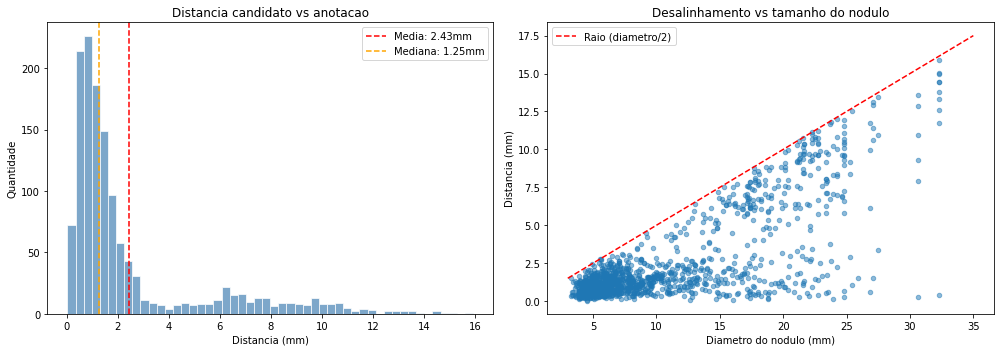

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(distances, bins=50, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].axvline(distances.mean(), color="red", linestyle="--",
                label=f"Media: {distances.mean():.2f}mm")
axes[0].axvline(np.median(distances), color="orange", linestyle="--",
                label=f"Mediana: {np.median(distances):.2f}mm")
axes[0].set_xlabel("Distancia (mm)")
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Distancia candidato vs anotacao")
axes[0].legend()

axes[1].scatter(matched_diameters, distances, alpha=0.5, s=20)
x_range = np.linspace(3, 35, 100)
axes[1].plot(x_range, x_range / 2, "r--", label="Raio (diametro/2)")
axes[1].set_xlabel("Diametro do nodulo (mm)")
axes[1].set_ylabel("Distancia (mm)")
axes[1].set_title("Desalinhamento vs tamanho do nodulo")
axes[1].legend()

plt.tight_layout()
plt.show()

Schauen Sie sich das rechte Diagramm an: alle Punkte liegen unterhalb der roten Linie (`Durchmesser / 2`). Das bedeutet, dass die Ausrichtungsabweichung immer kleiner ist als der Knotenradius. Ein gutes Zeichen -- der Abgleich kann sicher durchgeführt werden.

Bestätigen wir das mit Zahlen:

In [6]:
within_radius = (distances <= matched_diameters / 2).sum()
print(f"Innerhalb des Radius (Durchmesser/2): {within_radius}/{len(distances)} ({100*within_radius/len(distances):.1f}%)")

for factor in [0.6, 0.7, 0.8, 1.0]:
    within = (distances <= matched_diameters * factor).sum()
    print(f"  Innerhalb von Durchmesser*{factor}: {within}/{len(distances)} ({100*within/len(distances):.1f}%)")

Innerhalb des Radius (Durchmesser/2): 1351/1351 (100.0%)
  Innerhalb von Durchmesser*0.6: 1351/1351 (100.0%)
  Innerhalb von Durchmesser*0.7: 1351/1351 (100.0%)
  Innerhalb von Durchmesser*0.8: 1351/1351 (100.0%)
  Innerhalb von Durchmesser*1.0: 1351/1351 (100.0%)


100% der positiven Kandidaten liegen innerhalb des Radius (`Durchmesser/2`). Im nächsten Notebook verwenden wir `Durchmesser/4` pro Achse (was konservativer ist), um den Abgleich in der Praxis durchzuführen. Dieser Spielraum stellt sicher, dass beim Zusammenführen der CSVs kein Knoten verloren geht.